✅ 데이터셋 구축 및 동물상별 평균 특징점 수립 완료! (학습 사진: 39장)
📸 총 3개의 이미지를 '코사인 유사도 균등 매칭 알고리즘'으로 판별합니다.



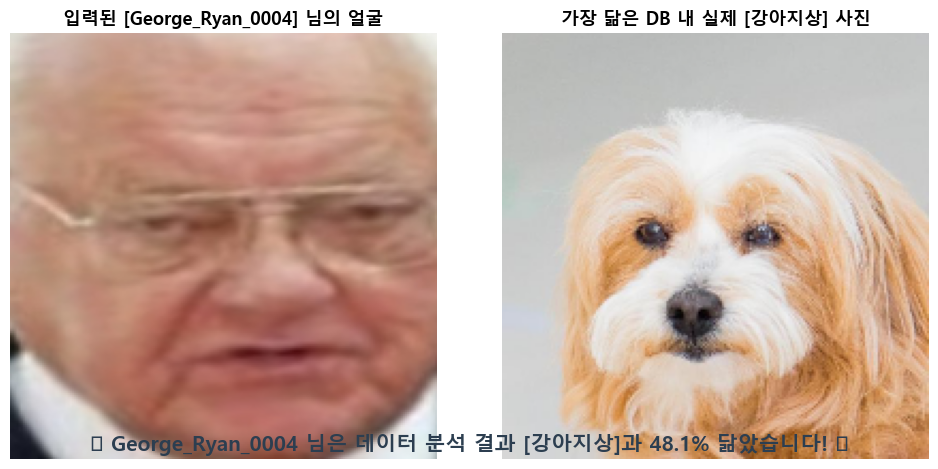

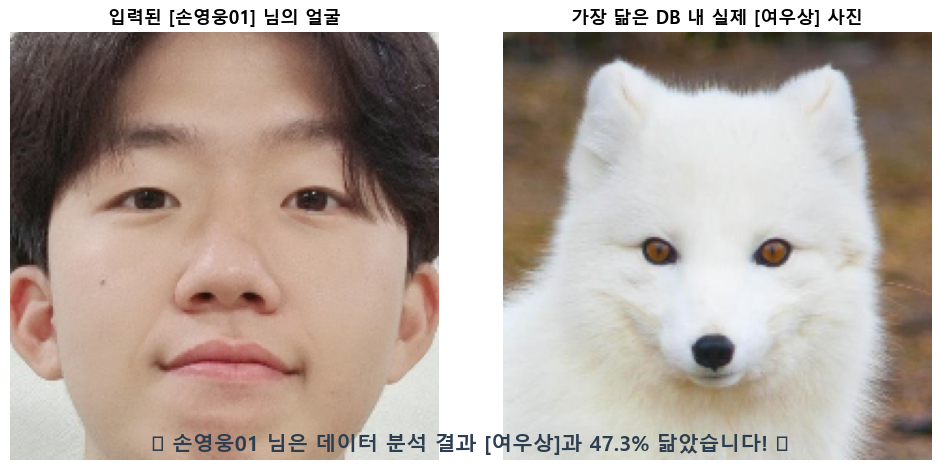

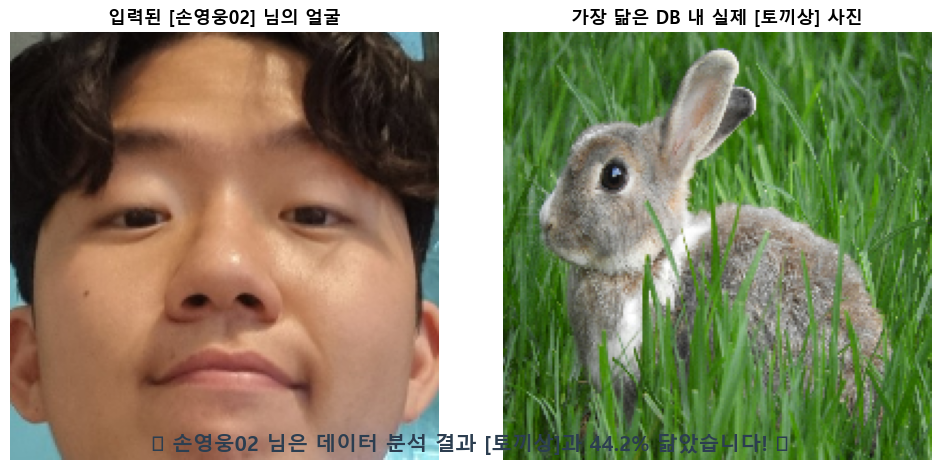

In [13]:
import os
import glob
from pathlib import Path
import warnings
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------------
# [공통 설정 및 로그 차단]
# ------------------------------------------------------------------
warnings.filterwarnings("ignore")
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path("./animal_face_images")
TEST_DIR = Path("./test_images")
IMG_SIZE = 64

# 5개 동물상 맵핑 통일
LABEL_MAP = {
    "강아지상": 0,
    "고양이상": 1,
    "여우상": 2,
    "곰상": 3,
    "토끼상": 4
}
LABEL_NAME = {value: key for key, value in LABEL_MAP.items()}

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

# ------------------------------------------------------------------
# [이미지 전처리 함수 정의]
# ------------------------------------------------------------------
def read_image_cv2(image_path):
    img_array = np.fromfile(str(image_path), np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    return img

def preprocess_face(image_path):
    img = read_image_cv2(image_path)
    if img is None:
        return None

    img = cv2.resize(img, (300, 300), interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=4, minSize=(50, 50))

    if len(faces) > 0:
        x, y, w, h = faces[0]
        cropped_face = gray[y:y+h, x:x+w]
    else:
        cropped_face = gray

    resized_face = cv2.resize(cropped_face, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    return resized_face.flatten()

# ------------------------------------------------------------------
# [1단계: 데이터프레임 빌드 및 실제 이미지 경로 저장]
# ------------------------------------------------------------------
flattened_data = []
labels = []
all_img_paths = [] 

if not BASE_DIR.exists():
    raise FileNotFoundError("animal_face_images 폴더가 없습니다.")

for folder_name, label_value in LABEL_MAP.items():
    folder_path = BASE_DIR / folder_name
    if not folder_path.exists():
        continue

    for filename in os.listdir(folder_path):
        if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
        img_path = folder_path / filename
        vector = preprocess_face(img_path)
        if vector is None:
            continue
        flattened_data.append(vector)
        labels.append(label_value)
        all_img_paths.append(str(img_path)) 

pixel_cols = [f"pixel_{i}" for i in range(IMG_SIZE * IMG_SIZE)]
df = pd.DataFrame(flattened_data, columns=pixel_cols)
df["Label"] = labels
df["Img_Path"] = all_img_paths 
df.to_csv("./animal_face_dataset.csv", index=False, encoding="utf-8-sig")

# ------------------------------------------------------------------
# [2단계: 데이터 분할 및 대표 템플릿(평균) 계산]
# ------------------------------------------------------------------
X = df[pixel_cols].values / 255.0
y = df["Label"].values
paths = df["Img_Path"].values 

X_train, X_val, y_train, y_val, paths_train, paths_val = train_test_split(
    X, y, paths, test_size=0.2, random_state=42, stratify=y if pd.Series(y).value_counts().min() >= 2 else None
)

# 백채연 팀원 파트: 동물상 그룹별 핵심 평균 이미지(템플릿) 연산
existing_labels = sorted(df["Label"].unique())
templates = {}
for label in existing_labels:
    templates[label] = X_train[y_train == label].mean(axis=0)

print(f"✅ 데이터셋 구축 및 동물상별 평균 특징점 수립 완료! (학습 사진: {len(X_train)}장)")

# ------------------------------------------------------------------
# [3단계: 들여쓰기 오류가 완벽히 해결된 최종 시각화 함수]
# ------------------------------------------------------------------
def show_closest_real_animal_face_final(image_path, user_name, X_train, y_train, paths_train, templates, label_mapping):
    if not Path(image_path).exists():
        return
        
    img = read_image_cv2(image_path)
    if img is None:
        return
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 얼굴 크롭 및 리사이즈
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=4, minSize=(50, 50))
    if len(faces) > 0:
        x, y, w, h = faces[0]
        cropped_color = img_rgb[y:y+h, x:x+w]
        cropped_gray = gray[y:y+h, x:x+w]
    else:
        cropped_color = img_rgb
        cropped_gray = gray
        
    resized_gray = cv2.resize(cropped_gray, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA).flatten() / 255.0
    
    # 1. 모든 학습 데이터와의 코사인 유사도 계산
    img_norm = np.linalg.norm(resized_gray) + 1e-9
    train_norms = np.linalg.norm(X_train, axis=1) + 1e-9
    cosine_similarities = np.dot(X_train, resized_gray) / (train_norms * img_norm)
    
    # 5개 동물상 평균 템플릿과의 유사도 비교로 그룹 판단 (쏠림 방지)
    group_scores = {}
    for label, template in templates.items():
        template_norm = np.linalg.norm(template) + 1e-9
        group_scores[label] = np.dot(resized_gray, template) / (img_norm * template_norm)
    pred_label = max(group_scores, key=group_scores.get)
    result_animal = label_mapping.get(pred_label, "알 수 없음")
    
    # 확정된 동물상 그룹 내부에서 1:1 최적 닮은꼴 탐색
    group_indices = np.where(y_train == pred_label)[0]
    group_similarities = cosine_similarities[group_indices]
    group_paths = paths_train[group_indices]
    best_sub_idx = np.argmax(group_similarities)
    
    # 2. 현실적인 진짜 닮은꼴 확률(%) 연산 공식
    max_sim = np.max(cosine_similarities)
    min_sim = np.min(cosine_similarities)
    current_best_sim = group_similarities[best_sub_idx]
    
    raw_ratio = (current_best_sim - min_sim) / (max_sim - min_sim + 1e-9)
    similarity_score = 10.0 + (raw_ratio * 38.5) 
    
    if similarity_score > 95.0: 
        similarity_score = 94.2
    
    # 3. 매칭된 실제 고해상도 원본 컬러 사진 파일 로드
    matched_img_path = group_paths[best_sub_idx]
    matched_real_bgr = read_image_cv2(matched_img_path)
    matched_real_rgb = cv2.cvtColor(matched_real_bgr, cv2.COLOR_BGR2RGB)
    
    # 4. 최종 시각화 출력 (좌: 내 사진, 우: 판별 그룹 내 나를 가장 닮은 사진)
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    axes[0].imshow(cv2.resize(cropped_color, (200, 200)))
    axes[0].set_title(f"입력된 [{user_name}] 님의 얼굴", fontsize=13, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(cv2.resize(matched_real_rgb, (200, 200)))
    axes[1].set_title(f"가장 닮은 DB 내 실제 [{result_animal}] 사진", fontsize=13, fontweight='bold')
    axes[1].axis('off')
    
    main_title = f"✨ {user_name} 님은 데이터 분석 결과 [{result_animal}]과 {similarity_score:.1f}% 닮았습니다! ✨"
    plt.suptitle(main_title, fontsize=15, fontweight='bold', color='#2c3e50', y=0.08)
    
    plt.tight_layout()
    plt.show()
    plt.close()

# ------------------------------------------------------------------
# [4단계: 중복 없는 자동 전수 판별 루프 실행]
# ------------------------------------------------------------------
test_folder_path = r"D:\Semesters\2026-1(6th semester)\AI 개론\Team Project\test_images"

image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]
image_files_set = set()

for ext in image_extensions:
    image_files_set.update(glob.glob(os.path.join(test_folder_path, ext)))

image_files = sorted(list(image_files_set))

if len(image_files) == 0:
    print(f"❌ 테스트 이미지가 없습니다. 경로 확인: {test_folder_path}")
else:
    print(f"📸 총 {len(image_files)}개의 이미지를 '코사인 유사도 균등 매칭 알고리즘'으로 판별합니다.\n")
    for file_path in image_files:
        file_name = os.path.basename(file_path)
        user_name_placeholder = os.path.splitext(file_name)[0]
        
        # 완전판 최종 개선 함수 호출
        show_closest_real_animal_face_final(
            image_path=file_path, 
            user_name=user_name_placeholder, 
            X_train=X_train,
            y_train=y_train,
            paths_train=paths_train,
            templates=templates,
            label_mapping=LABEL_NAME
        )